# Social Graphs and Interactions (02805) - Assignment 2


In [40]:
import requests
import json
import pandas as pd
import networkx as nx
import seaborn as sns
import matplotlib.pyplot as plt
from io import BytesIO
from collections import Counter
import numpy as np
from fa2_modified import ForceAtlas2
import matplotlib.colors as cm
from matplotlib.patches import Patch

# Part 2: Genres, Communities, and Plotting

For this part, we will explore the modularity measure $M$. We will do a deep dive into the network of rock performers and explore the communities of genres present in it.

## Part 2.1: Modularity and Genres

### Modularity Explained

As a point of departure, we will briefly describe the modularity measure in the context of networks.

**Modularity** $M$ is a measure of the quality of partitions in a graph or network. It measures how well a network is divided into groups (communities) compared to what would be expected by _random chance_. The higher $M$ is for a given partition, the better the community structure at hand is. This means that the nodes in that community have more edges between them than would be expected in a random network with the same degree distribution. At $M=0$, the network’s edges are distributed randomly with no group structure. In this case, we assign all nodes to the same community.

Modularity $M$ allows us to decide whether one community partition is better than another. It can help us predict which of the partitions predicted by a hierarchical method offer the best community structure (i.e., the partition that maximizes $M$).

We compute modularity $M$ as it's described in the Network Science textbook ([Chapter 9, Section 9.4](https://networksciencebook.com/chapter/9#modularity)). The formula from the book is shown below:

$$
M = \sum_{c=1}^{n_c} \left[ \frac{L_c}{L} - \left( \frac{k_c}{2L} \right)^2 \right]
$$

Where:

$$
\begin{align*}
L_c &: \text{Number of links within a community $c$} \\
L &: \text{Total number of links in the network} \\
k_c &: \text{Sum of degrees of nodes within a community $c$} \\
n_c &: \text{Number of communities}
\end{align*}
$$

### Goal and Objectives

Our goal is to examine community alignment with the music genres in our network of rock performers. To this end, we will explore the following:

- Calculate the genre-based modularity
- Detect communities using the Louvain method and calculate their modularity
- Compare the genre-based communities with the ones identified by the Louvain algorithm
- Generate the confusion matrix for the genres and communities
- Visualize the network with communities


### Part 2.2: Calculation of Modularity, Community Detection, and Comparison


We begin our analysis by loading our network.


In [4]:
url = "https://raw.githubusercontent.com/adamajane/social-graphs-and-interactions-02805-assignments/refs/heads/main/assignment_2/files/artists_graph_with_stats.gexf"

# Fetch file from GitHub
response = requests.get(url)
response.raise_for_status()

# Load into NetworkX
G = nx.read_gexf(BytesIO(response.content))
G = G.to_undirected()
print(
    f"Network successfully loaded: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges"
)

Network successfully loaded: 484 nodes, 6025 edges


#### Modularity Calculation

Below, we define a function that calculates modularity based on equation 9.12 in [Network Science, Chapter 9, Section 9.4](https://networksciencebook.com/chapter/9#modularity)


In [5]:
def calculate_modularity(G, communities):
    # Total number of edges in the network
    L = G.number_of_edges()
    M = 0.0

    if L == 0:
        raise ValueError("Graph has no edges")

    # Group nodes by community
    community_nodes = {}
    for node, comm in communities.items():
        community_nodes.setdefault(comm, set()).add(node)

    for c, nodes in community_nodes.items():
        # Subgraph of the current community
        subgraph = G.subgraph(nodes)

        # L_c = number of edges within this community
        L_c = subgraph.number_of_edges()

        # k_c = sum of degrees of nodes within the community
        k_c = sum(dict(G.degree(nodes)).values())

        # Add term for this community
        M += (L_c / L) - (k_c / (2 * L)) ** 2

    return M

Before we dive into the calculation of the genre-based modularity of our rock performer network, we want to note that the vast majority of the artists have `rock` listed as their primary musical genre. Therefore, if the `rock` genre is a large community, the network won't have that high a modularity. This is an important point to bear in mind for this section.

Nevertheless, let's start by computing the modularity of the network across all genres included to explore whether the musical styles naturally cluster into clear communities.


In [6]:
# Load genre data from JSON
with open("artist_genres.json", "r") as f:
    genre_data = json.load(f)

# Create a mapping from artist (node) to its primary genre
genre_map = {}
for artist in G.nodes():
    if artist in genre_data and len(genre_data[artist]) > 0:
        # Take the first listed genre as the representative one
        genre_map[artist] = genre_data[artist][0].lower()
    else:
        # If no genre data is found, assign "unknown"
        genre_map[artist] = "unknown"

# Calculate modularity using the genre-based partition
M_genre = calculate_modularity(G, genre_map)

print(f"Genre-based modularity (using first genre): {M_genre:.4f}")

Genre-based modularity (using first genre): 0.0970


When we include `rock` as a genre, we get a modularity of $M=0.0970$. This low value implies that the artists' genre connections do not form tightly separated genre-based groups. Including the `rock` label basically "swallows" most nodes, creating one giant, dense group in the process. This makes it difficult for the modularity measure to detect any meaningful structure in the network. Essentially, the network looks too homogenous as most edges are within the `rock` genre. Since `rock` is most of the graph, this doesn’t stand out compared to random chance. That is, the network appears almost random w.r.t. those genres.

In the hope of achieving a higher modularity score, we will now tweak the dataset by picking the first non-`rock` music genre for the performers with more than one genre listed. Below, we have adjusted the code to do just that.


In [7]:
# Load genre data from JSON
with open("artist_genres.json", "r") as f:
    genre_data = json.load(f)

# Assign first non-rock genre if possible
genre_map_nonrock = {}
for artist in G.nodes():
    genres = [g.lower() for g in genre_data.get(artist, [])]

    if not genres:
        genre_map_nonrock[artist] = "unknown"
        continue

    # Try to find the first genre that's not 'rock'
    non_rock_genres = [g for g in genres if g != "rock"]

    if non_rock_genres:
        genre_map_nonrock[artist] = non_rock_genres[0]
    else:
        # If all genres are 'rock', fall back to 'rock'
        genre_map_nonrock[artist] = "rock"

# Calculate modularity using this adjusted mapping
M_nonrock = calculate_modularity(G, genre_map_nonrock)

print(f"Genre-based modularity (first non-rock genre): {M_nonrock:.4f}")

Genre-based modularity (first non-rock genre): 0.1481


As we can see, the modularity acutally increases to $M = 0.1481$. This means that the heavy presence of the `rock` genre was indeed concealing insightful community structure in the network. By introducing clearer categorical distinctions, the network separates into smaller and more cohesive clusters that better reflect the genre-based communities. However, the increase is not significant, which still indicates that music genres provides a limited insight into the underlying communities in the network. That is, the genre explains _part_ of how the performers are connected, but it does not fuully account for the network's shape.

To further explore how these communities emerge and to quantify their cohesion, we can apply a community detection algorithm. To this end, we will ues the **Louvain** method, which optimizes modularity to uncover dense clusters within the network.


#### The Louvain Method for Community Detection


The Louvain algorithm detects communities in the network by maximizing the modularity measure. This approach differs from our previous genre-based one by examining the network's connections. Let's take a look.


In [8]:
# Detect communities using the Louvain method
louvain_comms = nx.community.louvain_communities(G, seed=42)
print(f"Detected {len(louvain_comms)} communities using Louvain method")

# Create a mapping from node to community label
louvain_map = {}
for i, comm in enumerate(louvain_comms):
    for node in comm:
        louvain_map[node] = i

# Calculate modularity for Louvain partition
M_louvain = calculate_modularity(G, louvain_map)

print(f"Louvain modularity: {M_louvain:.4f}")

Detected 4 communities using Louvain method
Louvain modularity: 0.3394


With the Louvain method, we get a modularity of $M = 0.3394$, which is noticably higher than the genre-based approach and near a value of an optimal partition. This implies that our graph has a stronger intrinsic community structure than what the genres alone explain. Put another way, this means that the artists' connections do not perfectly align with their listed music genres and that there are cross-genre clusters that the Louvain algorithm detects.


#### Partial Conclusion


Genres give a partial lens into the community structure, but they don’t fully align with the intrinsic clusters that arise from actual artist relationships. The network’s modularity is significantly stronger when communities are detected using the Louvain method, which suggests the rock performers are interconnected across subgenres more than its genre data would imply.

Now that we know how these partitions differ, we can visualize their relationship through a **confusion matrix** by comparing Louvain communities (rows) to genre labels (columns). This will tell us which genres dominate each community and whether certain genres cluster together.


### Part 2.3: Confusion Matrix comparing Communities vs. Genres

We start by calculating the confusion matrix $D$. It's done below.


Top 7 genres: ['rock', 'pop', 'metal', 'post-grunge', 'new wave', 'country', 'folk']
Top 7 communities: [2, 0, 3, 1]

Confusion matrix D (Top 7 genres × Top 7 communities):
               2    0   3   1
rock         178  150  86  44
pop           60   61   8   3
metal          2   23  72  29
post-grunge    0    9   2  32
new wave       8   22   1   0
country       15    3   4   0
folk          13    5   1   1

Normalized confusion matrix (row-wise proportions):
                    2         0         3         1
rock         0.388646  0.327511  0.187773  0.096070
pop          0.454545  0.462121  0.060606  0.022727
metal        0.015873  0.182540  0.571429  0.230159
post-grunge  0.000000  0.209302  0.046512  0.744186
new wave     0.258065  0.709677  0.032258  0.000000
country      0.681818  0.136364  0.181818  0.000000
folk         0.650000  0.250000  0.050000  0.050000


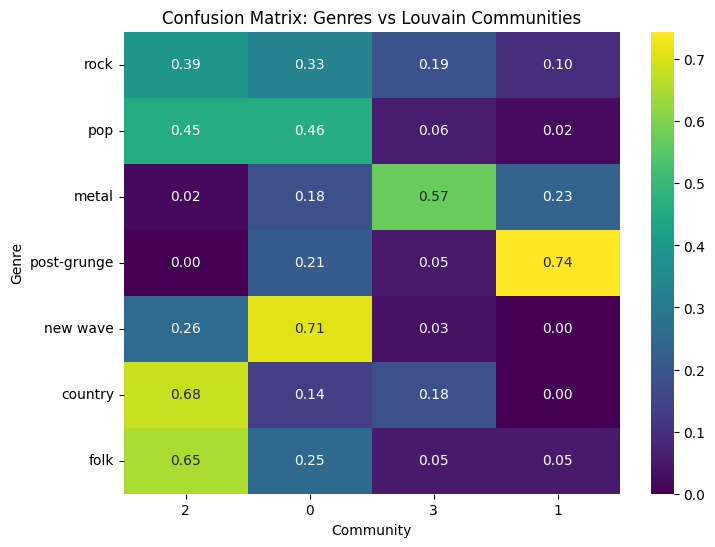

In [ ]:
# Identify top 7 genres
all_genres_flat = [g.lower() for genres in genre_data.values() for g in genres]
top7_genres = [g for g, _ in Counter(all_genres_flat).most_common(7)]
print("Top 7 genres:", top7_genres)

# Identify top 7 communities (by size)
comm_sizes = [(i, len(c)) for i, c in enumerate(louvain_comms)]
comm_sizes.sort(key=lambda x: x[1], reverse=True)
top7_comms = [i for i, _ in comm_sizes[:7]]
print("Top 7 communities:", top7_comms)

# Initialize empty matrix (genre × community)
D = pd.DataFrame(0, index=top7_genres, columns=top7_comms)

# Fill matrix based on overlapping membership
for node in G.nodes():
    # Skip nodes not in top 7 communities
    comm = louvain_map.get(node)
    if comm not in top7_comms:
        continue

    # Get node's genres (lowercase)
    node_genres = [g.lower() for g in genre_data.get(node, [])]

    # For each genre that’s one of the top 7, increment the appropriate cell
    for g in node_genres:
        if g in top7_genres:
            D.loc[g, comm] += 1

# Print confusion matrix
print("\nConfusion matrix D (Top 7 genres \u00d7 Top 7 communities):")
print(D)

# Normalize by genre (row-wise proportions)
D_normalized = D.div(D.sum(axis=1), axis=0)
print("\nNormalized confusion matrix (row-wise proportions):")
print(D_normalized)

# Confusion matrix heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(D_normalized, annot=True, cmap="viridis", fmt=".2f")
plt.xlabel("Community")
plt.ylabel("Genre")
plt.title("Confusion Matrix Heatmap: Genres vs Louvain Communities")
plt.show()

#### Partial Conclusion


From our confusion matrices, we observe that the communities detected by the Louvain algorithm only partially align with musical genres. For instance, `rock` artists are spread across multiple communities (mostly 2 and 0). This suggests that the `rock` genre is too broad to capture distinct network structures, which could reflect stylistic diversity within the genre. In contrast, `post-grunge` and `metal` show stronger alignment, with clear concentration in one or two communities. These may indicate more tightly connected sub-scenes of performers. Genres like `pop` and `new wave` overlap heavily with other genres’ communities, which could imply cross-genre collaborations or blending of styles.

Overall, while some communities correspond well to specific genres, others likely capture higher-level structures such as influences, collaborations, or time period clusters rather than genre boundaries alone.


### Part 2.4: Community Plotting and Visualization

Plot the communities and comment on your results.


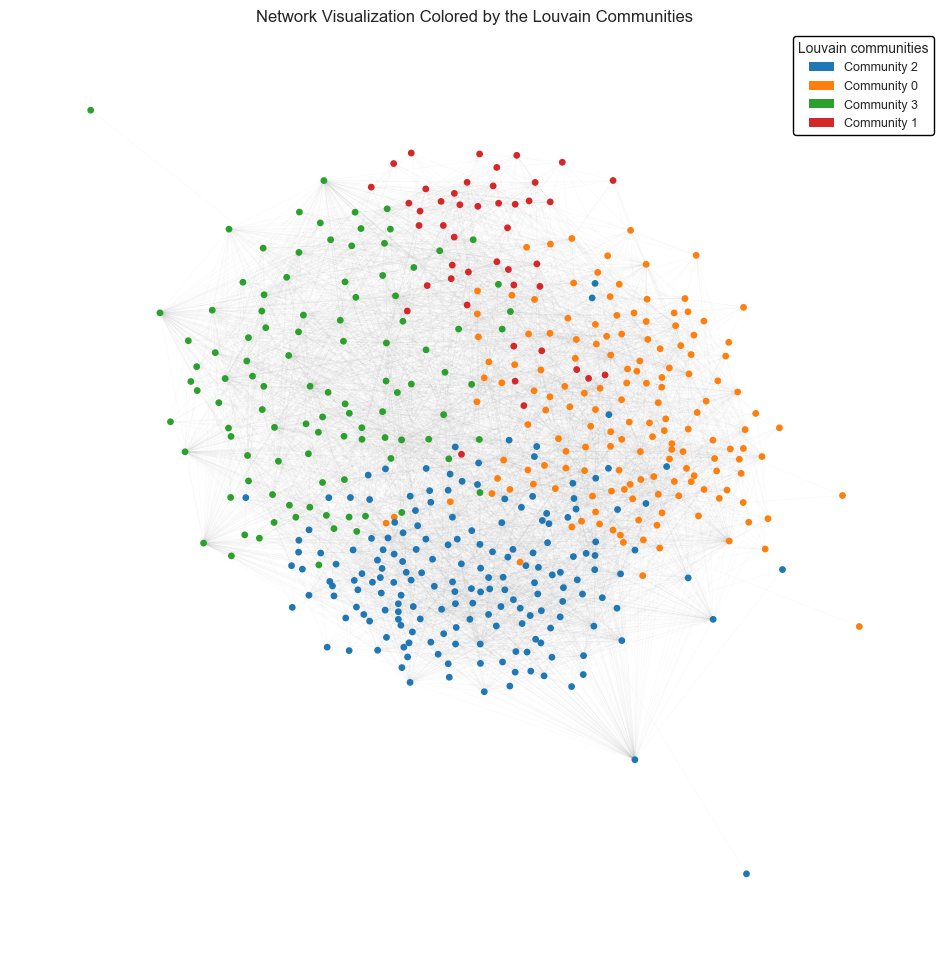

In [64]:
# ForcAtlas2 layout
forceatlas2 = ForceAtlas2(
    outboundAttractionDistribution=True,
    linLogMode=False,
    adjustSizes=False,
    edgeWeightInfluence=1.0,
    jitterTolerance=1.0,
    barnesHutOptimize=True,
    barnesHutTheta=1.2,
    scalingRatio=10.0,
    gravity=1.0,
    verbose=False,
)

# Compute ForceAtlas2 positions
pos = forceatlas2.forceatlas2_networkx_layout(G, pos=None, iterations=500)

# Color palette for the largest communities
top_n = 8
comm_sizes = sorted(
    ((idx, len(nodes)) for idx, nodes in enumerate(louvain_comms)),
    key=lambda x: x[1],
    reverse=True,
)
top_comm_ids = [comm for comm, _ in comm_sizes[:top_n]]
palette = sns.color_palette("tab10", n_colors=len(top_comm_ids))
community_palette = {comm: palette[i] for i, comm in enumerate(top_comm_ids)}
default_color = (0.85, 0.85, 0.85)

node_colors = [
    community_palette.get(louvain_map[node], default_color) for node in G.nodes()
]

plt.figure(figsize=(12, 12))
nx.draw_networkx_edges(G, pos, alpha=0.05, width=0.4, edge_color="gray")
nx.draw_networkx_nodes(G, pos, node_size=15, node_color=node_colors)

legend_handles = [
    Patch(
        facecolor=community_palette[comm],
        edgecolor="none",
        label=f"Community {comm}",
    )
    for comm in top_comm_ids
]

plt.legend(
    handles=legend_handles,
    loc="upper right",
    frameon=True,
    fancybox=True,
    framealpha=1.0,
    edgecolor="black",
    fontsize=9,
    title="Louvain communities",
)

plt.title("Network Visualization Colored by the Louvain Communities")
plt.axis("off")
plt.show()

#### Observations

In the above network, we observe the distinct clusters computed using the Louvain method. Each color represents a structural community, and we can clearly see several dense clusters with relatively few edges connecting them. This pattern indicates that artists within the same community are more closely linked while inter-community connections are sparser. The boundaries between the clusters aren’t perfectly sharp, which reflects the real-world overlap between musical genres and influences in rock music.

Overall, the visualization supports the modularity results, showing that the Louvain method captures an insightful community structure within the network.


# Part 3: TF-IDF to Understand Genres and Communities

## Part 3.1: TF-IDF Explained

**TF-IDF** (**T**erm **F**requency-**I**nverse **D**ocument **F**requency) measures the importance of a word within a document compared to its importance across all documents in a corpus. This is an interesting measure as it highlights the terms unique to a collection of text, which assists in identifying characteristic language of genres and communities. **TF** is a measure for a single term in a document. **IDF** measures it's relative rarity across the corpus.

TF-IDF is calculated using the formula: $$\text{TF-IDF}(t, d) = \text{TF}(t, d) \times \text{IDF}(t)$$

Where:

$$
\text{TF}(t, d) = \frac{\text{Number of times term } t \text{ appears in document } d}{\text{Total number of terms in } d} = \frac{f_{t,d}}{\sum_{t' \in d} f_{t',d}} \\[6pt]
\text{IDF}(t) = \log\left( \frac{N}{\text{n}_{t}} \right) \\[6pt]
$$

TF-IDF is useful for identifying unique keywords, comparing text similarity, and clustering or classifying documents based on their language patterns. In relation to genres and communities, it can help uncover distinctive language usage and reveal thematic differences across musical styles.
